In [1]:
from google.colab import files
uploaded = files.upload()

Saving project (1).xlsx to project (1).xlsx


In [3]:
import pandas as pd

df = pd.read_excel("project (1).xlsx")
df.head()

,order_date,total_orders,total_cancellations,wastage_flag,fraud_flag
0,2024-01-01,120,10,0,0
1,2024-01-02,135,15,0,0
2,2024-01-03,110,8,0,0
3,2024-01-04,150,20,0,0
4,2024-01-05,160,18,0,0


In [5]:
# convert date column to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# sort data (important for time series)
df = df.sort_values('order_date')

df.head()

,order_date,total_orders,total_cancellations,wastage_flag,fraud_flag
0,2024-01-01,120,10,0,0
1,2024-01-02,135,15,0,0
2,2024-01-03,110,8,0,0
3,2024-01-04,150,20,0,0
4,2024-01-05,160,18,0,0


In [6]:
data = df[['total_orders']]
data.head()

,total_orders
0,120
1,135
2,110
3,150
4,160


In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.14285714],
       [0.35714286],
       [0.        ],
       [0.57142857],
       [0.71428571]])

In [9]:
import numpy as np

X = []
y = []

for i in range(5, len(scaled_data)):
    X.append(scaled_data[i-5:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

print(X.shape, y.shape)

(40, 5, 1) (40, 1)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X, y, epochs=20, batch_size=8)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4836
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4131
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3501 
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2929
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2414 
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1933
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1501
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1101
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0782
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0564 
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0536 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0550 
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0551 
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0520 
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0500
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━

In [12]:
predictions = model.predict(X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step


In [13]:
predictions_actual = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y)

predictions_actual[:5]

array([[146.38367],
       [151.59943],
       [151.79677],
       [153.13603],
       [152.69809]], dtype=float32)

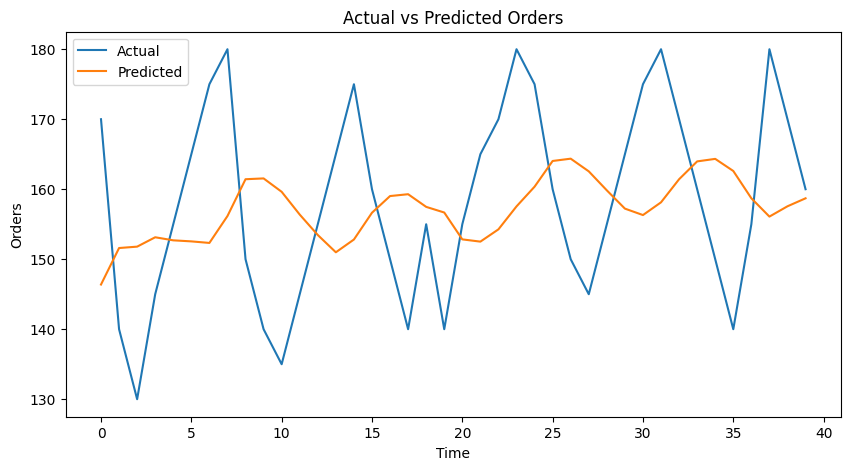

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_actual, label='Actual')
plt.plot(predictions_actual, label='Predicted')

plt.title('Actual vs Predicted Orders')
plt.xlabel('Time')
plt.ylabel('Orders')
plt.legend()

plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_actual, predictions_actual))
mae = mean_absolute_error(y_actual, predictions_actual)
mape = np.mean(np.abs((y_actual - predictions_actual) / y_actual)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 15.299263352914787
MAE: 13.284414291381836
MAPE: 8.434876953367025


In [16]:
window = 5
moving_avg = []

for i in range(window, len(y_actual) + window):
    moving_avg.append(np.mean(y_actual[i-window:i]))

moving_avg = np.array(moving_avg)

moving_avg[:5]

array([148., 147., 154., 164., 165.])

In [17]:
min_len = min(len(moving_avg), len(y_actual))

ma_rmse = np.sqrt(mean_squared_error(y_actual[:min_len], moving_avg[:min_len]))
ma_mae = mean_absolute_error(y_actual[:min_len], moving_avg[:min_len])

print("Moving Average RMSE:", ma_rmse)
print("Moving Average MAE:", ma_mae)

Moving Average RMSE: 13.923507550182892
Moving Average MAE: 11.83125
